In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn scipy mgwr
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap
from scipy import stats as stats
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import NearestNeighbors 

In [2]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df_2 = pd.DataFrame(housing.target, columns=['MedHouseVal'])
df = pd.concat([df, df_2], axis=1)

In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
df['log_AveRooms'] = np.log1p(df['AveRooms'])
df['log_AveBedrms'] = np.log1p(df['AveBedrms'])
df['log_AveOccup'] = np.log1p(df['AveOccup'])

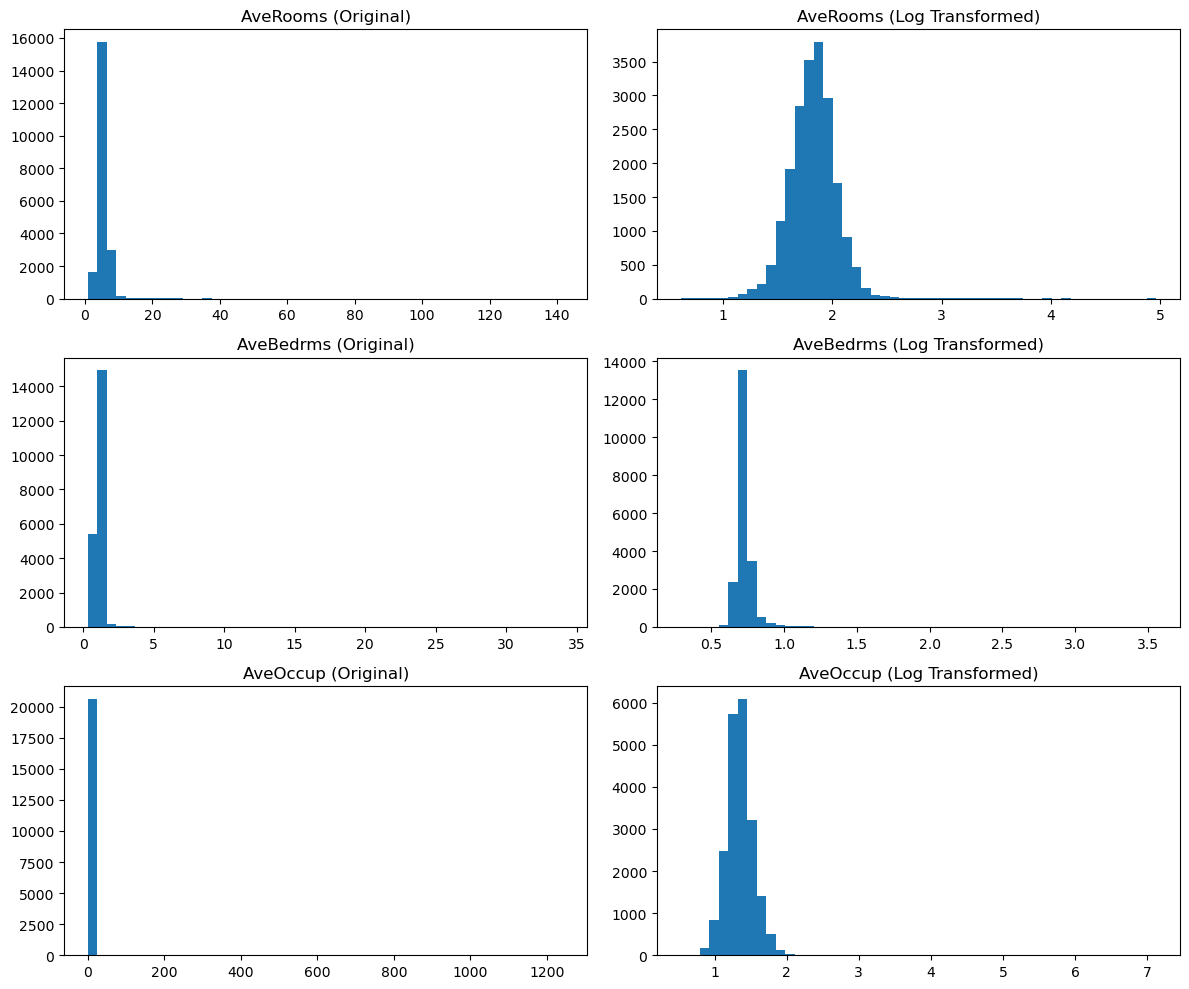

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for idx, col in enumerate(['AveRooms', 'AveBedrms', 'AveOccup']):
    axes[idx, 0].hist(df[col], bins=50)
    axes[idx, 0].set_title(f'{col} (Original)')
    axes[idx, 1].hist(df[f'log_{col}'], bins=50)
    axes[idx, 1].set_title(f'{col} (Log Transformed)')
plt.tight_layout()
plt.show()

Number of outliers detected: 1107
Number of records after removing outliers: 19533


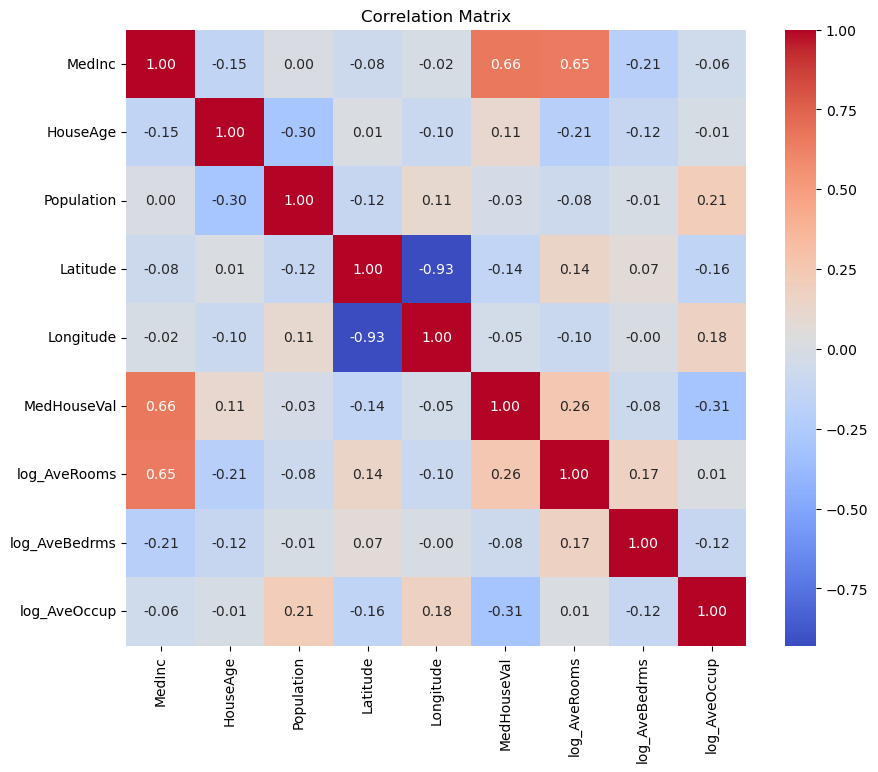

In [6]:
df.drop(['AveRooms', 'AveBedrms', 'AveOccup'], axis=1
, inplace=True)
#checking for outliers using z-score
z_scores = np.abs(stats.zscore(df))
outliers = (z_scores > 3).any(axis=1)
print(f'Number of outliers detected: {outliers.sum()}')
#removing outliers
df_cleaned = df[~outliers]
print(f'Number of records after removing outliers: {len(df_cleaned)}')
#correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt
='.2f')
plt.title('Correlation Matrix')
plt.show()

In [8]:
target = df_cleaned['MedHouseVal']
# what we want to predict

features = ['MedInc', 'HouseAge', 'Population', 'Latitude', 'Longitude',
            'log_AveRooms', 'log_AveBedrms', 'log_AveOccup']
#all the variables 

X = df_cleaned[features]
#X values
y = target
#Y = median house value
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
baselline_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
baselline_model.fit(X_train_scaled, y_train)
baseline_score = baselline_model.score(X_test_scaled, y_test)

print("Model Architecture:")
print(f"  Hidden layers: {baselline_model.hidden_layer_sizes}")
print(f"  Activation: {baselline_model.activation}")
print(f"  Solver: {baselline_model.solver}")
print(f"  Max iterations: {baselline_model.max_iter}")

Model Architecture:
  Hidden layers: (100,)
  Activation: relu
  Solver: adam
  Max iterations: 500


In [10]:
y_pred_train = baselline_model.predict(X_train_scaled)
y_pred_test  = baselline_model.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse  = mean_squared_error(y_test,  y_pred_test)
train_r2  = r2_score(y_train, y_pred_train)
test_r2   = r2_score(y_test,  y_pred_test)

print(f'Train MSE: {train_mse:.4f}, Train R^2: {train_r2:.4f}')
print(f'Test MSE: {test_mse:.4f}, Test R^2: {test_r2:.4f}')

Train MSE: 0.2459, Train R^2: 0.7986
Test MSE: 0.2684, Test R^2: 0.7866


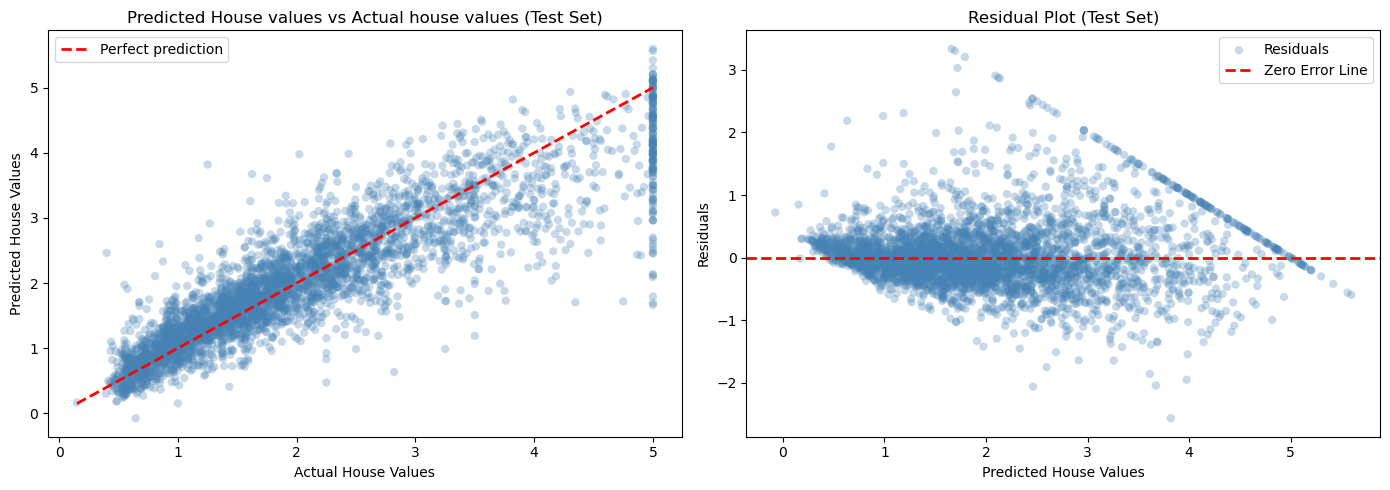

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Predicted vs Actual ---
axes[0].scatter(y_test, y_pred_test, alpha=0.3, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], #draws a diagonal line representing perfect predictions
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual House Values')
axes[0].set_ylabel('Predicted House Values')
axes[0].set_title('Predicted House values vs Actual house values (Test Set)')
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3, color='steelblue', edgecolors='none')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted House Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot (Test Set)')
axes[1].legend(['Residuals', 
                'Zero Error Line'])

plt.tight_layout()
plt.show()

In [12]:
k = 5  # number of neighbours

# Use only training coordinates to define neighbours
train_coords = X_train[['Latitude', 'Longitude']].values
test_coords = X_test[['Latitude', 'Longitude']].values

In [13]:
# Fit nearest neighbours on TRAINING data only
# This avoids using test labels when constructing neighbourhood features
nn = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
nn.fit(train_coords)

train_distances, train_indices = nn.kneighbors(train_coords)

# Remove self-neighbour
train_distances = train_distances[:, 1:]
train_indices = train_indices[:, 1:]

In [14]:
# Convert y_train to numpy array for indexing
y_train_array = y_train.to_numpy()

# Neighbourhood feature 1: average neighbour house value (training labels only)
train_mean_neighbour_price = y_train_array[train_indices].mean(axis=1)

# Neighbourhood feature 2: average distance to neighbours
train_mean_neighbour_distance = train_distances.mean(axis=1)

# Neighbourhood feature 3: number of neighbours
train_num_neighbours = np.full(len(X_train), k)

test_distances, test_indices = nn.kneighbors(test_coords, n_neighbors=k)

test_mean_neighbour_price = y_train_array[test_indices].mean(axis=1)
test_mean_neighbour_distance = test_distances.mean(axis=1)
test_num_neighbours = np.full(len(X_test), k)

X_train_graph = X_train.copy()
X_test_graph = X_test.copy()

In [15]:
X_train_graph['NeighbourMeanPrice'] = train_mean_neighbour_price
X_train_graph['NeighbourMeanDistance'] = train_mean_neighbour_distance
X_train_graph['NumNeighbours'] = train_num_neighbours

X_test_graph['NeighbourMeanPrice'] = test_mean_neighbour_price
X_test_graph['NeighbourMeanDistance'] = test_mean_neighbour_distance
X_test_graph['NumNeighbours'] = test_num_neighbours

print("New neighbourhood-based features added:")
print(['NeighbourMeanPrice', 'NeighbourMeanDistance', 'NumNeighbours'])

New neighbourhood-based features added:
['NeighbourMeanPrice', 'NeighbourMeanDistance', 'NumNeighbours']


In [16]:
scaler_graph = StandardScaler()
X_train_graph_scaled = scaler_graph.fit_transform(X_train_graph)
X_test_graph_scaled = scaler_graph.transform(X_test_graph)

# Train second neural network
graph_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
graph_model.fit(X_train_graph_scaled, y_train)

# Predictions
y_pred_train_graph = graph_model.predict(X_train_graph_scaled)
y_pred_test_graph = graph_model.predict(X_test_graph_scaled)

# Metrics
train_mse_graph = mean_squared_error(y_train, y_pred_train_graph)
test_mse_graph = mean_squared_error(y_test, y_pred_test_graph)
train_r2_graph = r2_score(y_train, y_pred_train_graph)
test_r2_graph = r2_score(y_test, y_pred_test_graph)

In [18]:
print("\nEnhanced Model (with neighbourhood features):")
print(f"Train MSE: {train_mse_graph:.4f}, Train R^2: {train_r2_graph:.4f}")
print(f"Test MSE: {test_mse_graph:.4f}, Test R^2: {test_r2_graph:.4f}")

print("\nModel Comparison:")
print(f"Baseline Test MSE:  {test_mse:.4f}")
print(f"Enhanced Test MSE:  {test_mse_graph:.4f}")
print(f"Baseline Test R^2:  {test_r2:.4f}")
print(f"Enhanced Test R^2:  {test_r2_graph:.4f}")

if test_mse_graph < test_mse:
    print("The enhanced model has a lower test MSE, so neighbourhood features improved performance.")
else:
    print("The enhanced model did not improve test MSE.")

if test_r2_graph > test_r2:
    print("The enhanced model has a higher test R^2, so neighbourhood features improved explanatory power.")
else:
    print("The enhanced model did not improve test R^2.")
    


Enhanced Model (with neighbourhood features):
Train MSE: 0.1455, Train R^2: 0.8808
Test MSE: 0.1723, Test R^2: 0.8630

Model Comparison:
Baseline Test MSE:  0.2684
Enhanced Test MSE:  0.1723
Baseline Test R^2:  0.7866
Enhanced Test R^2:  0.8630
The enhanced model has a lower test MSE, so neighbourhood features improved performance.
The enhanced model has a higher test R^2, so neighbourhood features improved explanatory power.


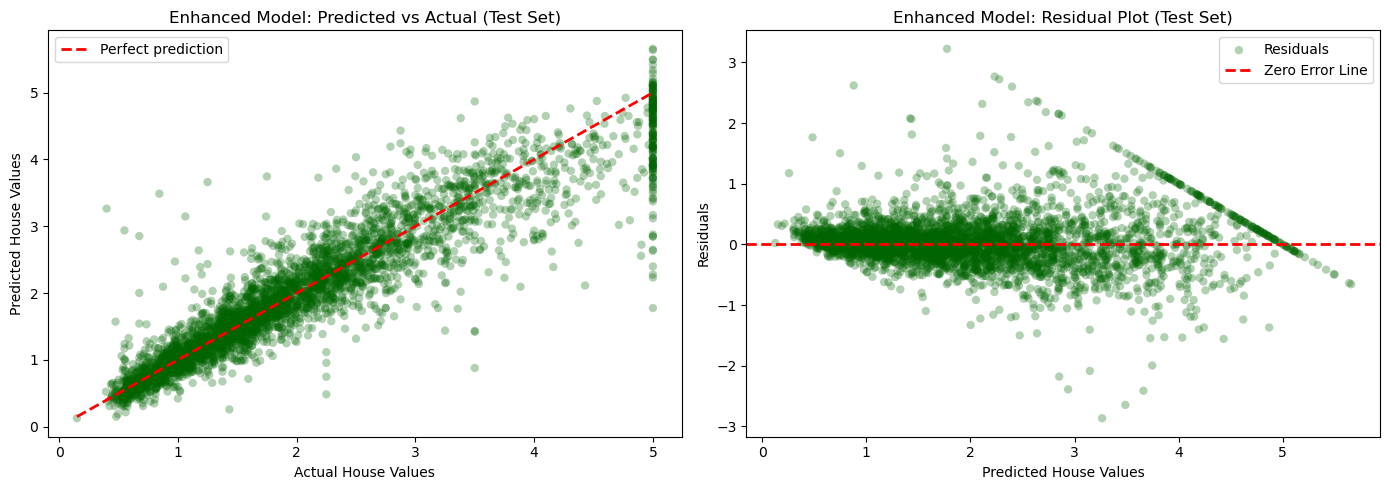

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test_graph, alpha=0.3, color='darkgreen', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual House Values')
axes[0].set_ylabel('Predicted House Values')
axes[0].set_title('Enhanced Model: Predicted vs Actual (Test Set)')
axes[0].legend()

# Residual plot
residuals_graph = y_test - y_pred_test_graph
axes[1].scatter(y_pred_test_graph, residuals_graph, alpha=0.3, color='darkgreen', edgecolors='none')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted House Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Enhanced Model: Residual Plot (Test Set)')
axes[1].legend(['Residuals', 'Zero Error Line'])

plt.tight_layout()
plt.show()
